# Quantum Computing

# 1. Fair and Biased Coin Flip Solution

One of the powers of quantum is that we can easily generate coin flips by coding a simple circuit and measuring the probabilities of our qubit states. Let's assign a 'Heads' coin flip to our qubit outcome '0' and assign a 'Tails' flip to our qubit outcome '1'. Here, we will construct quantum circuit that create a fair 50-50 distribution, a 70-30 biased distrubtion, and a 0-100 completely biased distribution.

## Necessary Imports

In [4]:
%%capture
!pip install pyquil -q

In [30]:
# Load the necessary packages and libraries
from __future__ import annotations
from pyquil.quil import Program
from pyquil.gates import *
from pyquil.quilbase import Gate
from IPython.display import Image
from random import *
import numpy as np
import math
import time
from pyquil.quil  import Program
from pyquil.gates import *
from random import *
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

We create a Numpy Quantum Virtual Machine through using single-qubit Clifford gates (H, X, Y, Z, I) plus the parametric rotation gates RX, RY, RZ and the two-qubit CNOT gate. The simulator uses exact unitary matrix multiplication; it is intended for small circuits (≲ 12 qubits).

In [6]:
# Numpy-based QVM simulator (replaces pyquil 2.x QVMConnection) in Colab

class WavefunctionResult:
    """
    Immutable container for a quantum state vector.

    Mirrors the interface of the ``WavefunctionResult`` object returned by
    ``pyquil 2.x``'s ``QVMConnection.wavefunction()``, so existing circuit
    code requires no changes.

    Parameters
    ----------
    amplitudes : np.ndarray of complex
        Full state-vector of length ``2**n_qubits`` in the computational basis,
        ordered from ``|0…0⟩`` (index 0) to ``|1…1⟩`` (index 2**n_qubits - 1).
    n_qubits : int
        Number of qubits in the register.

    Examples
    --------
    >>> import numpy as np
    >>> amp = np.array([1/np.sqrt(2), 0, 0, 1/np.sqrt(2)], dtype=complex)
    >>> wfr = WavefunctionResult(amp, n_qubits=2)
    >>> wfr.get_outcome_probs()
    {'00': 0.5, '01': 0.0, '10': 0.0, '11': 0.5}
    """

    def __init__(self, amplitudes: np.ndarray, n_qubits: int) -> None:
        self.amplitudes = amplitudes
        self.n_qubits   = n_qubits

    def get_outcome_probs(self) -> dict[str, float]:
        """
        Compute the Born-rule probability for every computational basis state.

        Returns
        -------
        dict[str, float]
            Keys are zero-padded binary strings (e.g. ``'01'``); values are
            real probabilities in ``[0, 1]`` that sum to 1.
        """
        return {
            format(i, f"0{self.n_qubits}b"): float(np.abs(amp) ** 2)
            for i, amp in enumerate(self.amplitudes)
        }

    def __str__(self) -> str:
        """
        Return a Dirac-notation string for non-negligible amplitudes.

        Returns
        -------
        str
            Human-readable superposition, e.g.
            ``'(0.7071+0j)|00> + (0.7071+0j)|11>'``.
            Amplitudes smaller than ``1e-10`` in magnitude are suppressed.
        """
        terms = [
            f"({amp:.10f})|{format(i, f'0{self.n_qubits}b')}>"
            for i, amp in enumerate(self.amplitudes)
            if abs(amp) > 1e-10
        ]
        return " + ".join(terms)

    def __repr__(self) -> str:
        return f"WavefunctionResult(n_qubits={self.n_qubits})"


class NumpyQVM:
    """
    NumPy quantum virtual machine.

    Supports all single-qubit Clifford gates (H, X, Y, Z, I) plus the parametric
    rotation gates RX, RY, RZ and the two-qubit CNOT gate.  The simulator uses
    exact unitary matrix multiplication; it is intended for small circuits
    (≲ 12 qubits) used in coursework.

    Notes
    -----
    The qubit register is always initialised in the all-zero state
    ``|0…0⟩``.  The number of qubits is inferred automatically from the
    highest qubit index appearing in the supplied ``Program``.

    Examples
    --------
    >>> from pyquil.quil   import Program
    >>> from pyquil.gates  import H, CNOT
    >>> qvm = NumpyQVM()
    >>> p   = Program(H(0), CNOT(0, 1))
    >>> wf  = qvm.wavefunction(p)
    >>> wf.get_outcome_probs()
    {'00': 0.5, '01': 0.0, '10': 0.0, '11': 0.5}
    """

    _STATIC_GATES: dict[str, np.ndarray] = {
        "H": np.array([[1,  1], [ 1, -1]], dtype=complex) / np.sqrt(2),
        "X": np.array([[0,  1], [ 1,  0]], dtype=complex),
        "Y": np.array([[0, -1j],[1j,  0]], dtype=complex),
        "Z": np.array([[1,  0], [ 0, -1]], dtype=complex),
        "I": np.eye(2, dtype=complex),
    }

    def _gate_matrix(self, inst) -> np.ndarray:
        """
        Return the 2×2 unitary matrix for a single-qubit gate instruction.

        Parameters
        ----------
        inst : pyquil.quilbase.Gate
            A pyQuil gate instruction.  Must be either a static Clifford gate
            (H, X, Y, Z, I) or a parametric rotation gate (RX, RY, RZ).

        Returns
        -------
        np.ndarray, shape (2, 2), dtype complex
            Unitary matrix in the ``{|0⟩, |1⟩}`` basis.

        Raises
        ------
        ValueError
            If ``inst.name`` is not one of the supported gate identifiers.
        """
        name = inst.name
        if name in self._STATIC_GATES:
            return self._STATIC_GATES[name]

        # pyQuil wraps angles in quil expression objects; coerce to float.
        param = inst.params[0]
        try:
            t = float(param)
        except (TypeError, ValueError):
            t = float(np.real(complex(param)))

        half = t / 2.0
        if name == "RX":
            return np.array(
                [[ np.cos(half),       -1j * np.sin(half)],
                 [-1j * np.sin(half),   np.cos(half)     ]],
                dtype=complex,
            )
        if name == "RY":
            return np.array(
                [[np.cos(half), -np.sin(half)],
                 [np.sin(half),  np.cos(half)]],
                dtype=complex,
            )
        if name == "RZ":
            return np.array(
                [[np.exp(-1j * half), 0                ],
                 [0,                  np.exp(1j * half)]],
                dtype=complex,
            )
        raise ValueError(f"Unsupported gate: '{name}'")

    def _embed(self, gate_mat: np.ndarray, qubit: int, n_qubits: int) -> np.ndarray:
        """
        Lift a single-qubit gate into the full *n*-qubit Hilbert space via
        tensor product.

        The gate acts on ``qubit``; all other qubits receive the identity.

        Parameters
        ----------
        gate_mat : np.ndarray, shape (2, 2)
            Single-qubit unitary matrix.
        qubit : int
            Zero-based qubit index on which ``gate_mat`` acts.
        n_qubits : int
            Total number of qubits in the register.

        Returns
        -------
        np.ndarray, shape (2**n_qubits, 2**n_qubits), dtype complex
            Full-register unitary operator.
        """
        ops     = [np.eye(2, dtype=complex)] * n_qubits
        ops[qubit] = gate_mat
        result  = ops[0]
        for op in ops[1:]:
            result = np.kron(result, op)
        return result

    def _embed_cnot(self, control: int, target: int, n_qubits: int) -> np.ndarray:
        """
        Build the full-register unitary for a CNOT gate.

        Parameters
        ----------
        control : int
            Zero-based index of the control qubit.
        target : int
            Zero-based index of the target qubit.
        n_qubits : int
            Total number of qubits in the register.

        Returns
        -------
        np.ndarray, shape (2**n_qubits, 2**n_qubits), dtype complex
            Sparse-like dense unitary matrix for the CNOT operation.
        """
        dim = 2 ** n_qubits
        mat = np.eye(dim, dtype=complex)
        for i in range(dim):
            bits = list(map(int, format(i, f"0{n_qubits}b")))
            if bits[control] == 1:
                bits[target] ^= 1
                j            = int("".join(map(str, bits)), 2)
                mat[i, i]    = 0.0
                mat[j, i]    = 1.0
        return mat

    def wavefunction(self, program: Program) -> WavefunctionResult:
        """
        Simulate a pyQuil ``Program`` and return the output state vector.

        The register is initialised in ``|0…0⟩``.  Gates are applied in
        program order by left-multiplying the current state vector with each
        gate's full-register unitary.

        Parameters
        ----------
        program : pyquil.quil.Program
            A pyQuil quantum circuit.  Supported instructions: H, X, Y, Z, I,
            RX, RY, RZ, CNOT.  All other instructions (e.g. ``DECLARE``,
            ``MEASURE``) are silently skipped.

        Returns
        -------
        WavefunctionResult
            Container holding the final state vector and qubit count.

        Notes
        -----
        The qubit count is set to ``max(qubit_index) + 1``, so sparse
        indexing (e.g. using only qubits 0 and 3) will allocate a
        4-qubit register.
        """
        from pyquil.quilbase import Gate

        # infer register size from highest qubit index
        qubit_indices = {
            q.index
            for inst in program.instructions
            if isinstance(inst, Gate)
            for q in inst.qubits
        }
        n_qubits = max(qubit_indices) + 1 if qubit_indices else 1

        # initialise |0…0⟩
        state    = np.zeros(2 ** n_qubits, dtype=complex)
        state[0] = 1.0

        # apply gates sequentially
        for inst in program.instructions:
            if not isinstance(inst, Gate):
                continue
            if inst.name == "CNOT":
                mat = self._embed_cnot(
                    inst.qubits[0].index, inst.qubits[1].index, n_qubits
                )
            else:
                mat = self._embed(
                    self._gate_matrix(inst), inst.qubits[0].index, n_qubits
                )
            state = mat @ state

        return WavefunctionResult(state, n_qubits)

# Replace qvm = api.QVMConnection()
qvm = NumpyQVM()

## Notation Tricks

In [7]:
n_qubits = 1  # Sets the number of qubits or coin flips

theta = math.pi  # Sets the 1-qubit gate rotation angle theta to pi

main_program = Program()        # Creates a quantum circuit program

main_program += H(0)            # Hadamard Gate on the 0th qubit

main_program += X(0)            # Not Gate on the 0th qubit

main_program += RZ(theta, 0)    # Pauli Z Rotation by angle theta on the 0th qubit

main_program += RX(theta, 0)    # Pauli X Rotation by angle theta on the 0th qubit

main_program += RY(theta, 0)    # Pauli Y Rotation by angle theta on the 0th qubit

wave_function = qvm.wavefunction(main_program)   # Get the output wavefunction
probs_dist    = wave_function.get_outcome_probs() # Get the probability distribution
print(probs_dist)

{'0': 0.4999999999999999, '1': 0.4999999999999999}


In [8]:
def upload_files():
  from google.colab import files
  uploaded = files.upload()
  for k, v in uploaded.items():
    open(k, 'wb').write(v)
  return list(uploaded.keys())

In [9]:
upload_files()

Saving Bars and stripes.png to Bars and stripes.png
Saving Two quibit entangler.png to Two quibit entangler.png
Saving Not Gate 0-100 Biased Coin.png to Not Gate 0-100 Biased Coin.png
Saving Y-Rotation 70-30 Biased Coin.png to Y-Rotation 70-30 Biased Coin.png
Saving Hadamard Gate Fair Coin.png to Hadamard Gate Fair Coin.png


['Bars and stripes.png',
 'Two quibit entangler.png',
 'Not Gate 0-100 Biased Coin.png',
 'Y-Rotation 70-30 Biased Coin.png',
 'Hadamard Gate Fair Coin.png']

## Circuit 1: Fair Coin

In order to generate a fair coin distribution, we want the probability of getting a 'Heads' to be the same as the probability of getting a 'Tails'.

In [10]:
n_qubits = 1 #Sets the number of qubits or coin flips
main_program = Program() #Creates a quantum circuit program
for i in range(n_qubits):
    main_program += H(i) #Performs a Hadamard Gate on the ith qubit
wave_function =  qvm.wavefunction(main_program) #Get the output quantum circuit wavefunction
probs_dist    =  wave_function.get_outcome_probs()  #Get the probability distribution
print(probs_dist)

{'0': 0.4999999999999999, '1': 0.4999999999999999}


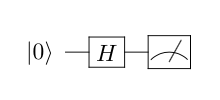

In [11]:
Image('Hadamard Gate Fair Coin.png')

## Circuit 2: 70-30 Biased Coin

In order to generate a 70-30 biased coin distribution, we want the probability of getting a 'Heads' to be 0.7 and the probability of getting a 'Tails' to be 0.3. In order to find the apropriate angle for our rotation, we need to do a bit of a guess and check.

In [12]:
main_program = Program() #Creates a quantum circuit program
phi = 2*np.arccos(np.sqrt(0.7))
main_program += RY(phi,0) #Performs a Y-Rotation with the angle phi on the 0th qubit
wave_function =  qvm.wavefunction(main_program) #Get the output quantum circuit wavefunction
print(wave_function)
probs_dist = wave_function.get_outcome_probs()  #Get the probability distribution
print(probs_dist)

(0.8366600265+0.0000000000j)|0> + (0.5477225575+0.0000000000j)|1>
{'0': 0.7000000000000001, '1': 0.29999999999999993}


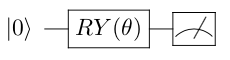

In [13]:
Image('Y-Rotation 70-30 Biased Coin.png')

## Circuit 3: 0-100 Biased Coin

In order to generate a 0-100 biased coin distribution, we want the probability of getting a 'Heads' to be 0 and the probability of getting a 'Tails' to be 1.

In [14]:
main_program = Program() #Creates a quantum circuit program
main_program += X(0) #Performs a Not Gate on the 0th qubit
wave_function =  qvm.wavefunction(main_program) #Get the output quantum circuit wavefunction
probs_dist    =  wave_function.get_outcome_probs()  #Get the probability distribution
print(probs_dist)

{'0': 0.0, '1': 1.0}


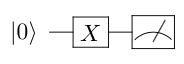

In [15]:
Image('Not Gate 0-100 Biased Coin.png')

In [16]:
# Another solution, with an RX gate and a rotation angle of 0
main_program = Program() #Creates a quantum circuit program
main_program += RX(np.pi,0) #Performs an RX Gate with angle pi on the 0th qubit
wave_function =  qvm.wavefunction(main_program) #Get the output quantum circuit wavefunction
probs_dist    =  wave_function.get_outcome_probs()  #Get the probability distribution
print(probs_dist)

{'0': 3.749399456654644e-33, '1': 1.0}


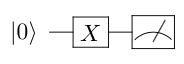

In [17]:
Image('Not Gate 0-100 Biased Coin.png')

# Quantum Entanglement

An additional power of quantum is that we can entangle two particles or pieces of information together such that having the knowledge of one piece will provide us with knowledge about the other. There are different ways in which we can generate entanglement using quantum gates, but the one requirement is that we utilize two-qubit gates. These gates are actually difficult to implement physically and therefore, remain a limitation of near-term quantum computing. Thus, it is important that we find ways to create short depth circuits that use less two-qubit gates.

Here, we will construct a quantum circuit that creates a Bell State for two-qubits, which is what we know as perfect or maximum entanglement. For a challenge, you may also add on qubits and see how this entanglement becomes harder to generate with an increased number of qubits!

## Circuit 4: Two qubit entangler

In order to entangle two qubits, we need to utilize a two qubit CNOT gate as well as our single qubit rotation gates. We are looking to generate the state with an equal probability on '00' and '11'.

In [18]:
main_program = Program() #Creates a quantum circuit program
main_program += H(0) #Performs a Hadamard Gate on the 0th qubit
main_program += CNOT(0,1) #Performs a CNOT Gate on the control 0th qubit to the target 1st qubit
wave_function =  qvm.wavefunction(main_program) #Get the output quantum circuit wavefunction
probs_dist    =  wave_function.get_outcome_probs()  #Get the probability distribution
print(probs_dist)

{'00': 0.4999999999999999, '01': 0.0, '10': 0.0, '11': 0.4999999999999999}


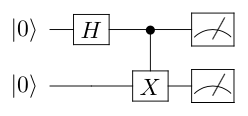

In [19]:
Image('Two quibit entangler.png')

## Circuit 5: Another two qubit entangler

Build a circuit that generates the state with an equal probability on '01' and '10', and zero probability on '00' and '11'.

In [20]:
# All we need to do is to add an NOT gate on any qubit at the end of the previous circuit

main_program = Program() #Creates a quantum circuit program
main_program += H(0) #Performs a Hadamard Gate on the 0th qubit
main_program += CNOT(0,1) #Performs a CNOT Gate on the control 0th qubit to the target 1st qubit
main_program += X(0)
wave_function =  qvm.wavefunction(main_program) #Get the output quantum circuit wavefunction
probs_dist    =  wave_function.get_outcome_probs()  #Get the probability distribution
print(probs_dist)

{'00': 0.0, '01': 0.4999999999999999, '10': 0.4999999999999999, '11': 0.0}


# Entangle More Qubits

An additional power of quantum is that we can entangle two particles or pieces of information together such that having the knowledge of one piece will provide us with knowledge about the other. There are different ways in which we can generate entanglement using quantum gates, but the one requirement is that we utilize two-qubit gates. These gates are actually difficult to implement physically and therefore, remain a limitation of near-term quantum computing. Thus, it is important that we find ways to create short depth circuits that use less two-qubit gates.

This entanglement becomes harder to generate with an increased number of qubits!


## Circuit 6: A Challenge

Try to create the state of an equal probability for '0000' and '1111' (and zero probability for all the other states). This is actually a place where machine learning can help quantum! Have a go in playing around with the angles below and introduce new gates!


In [21]:
# Goal: equal probability ONLY on '0000' and '1111'  (classic GHZ state)

main_program = Program()         #Creates a quantum circuit program
main_program += H(0)             #Hadamard creates superposition on qubit 0
main_program += CNOT(0, 1)       #Entangle qubit 1
main_program += CNOT(0, 2)       #Entangle qubit 2
main_program += CNOT(0, 3)       #Entangle qubit 3

wave_function = qvm.wavefunction(main_program)
probs_dist    = wave_function.get_outcome_probs()
print(probs_dist)

{'0000': 0.4999999999999999, '0001': 0.0, '0010': 0.0, '0011': 0.0, '0100': 0.0, '0101': 0.0, '0110': 0.0, '0111': 0.0, '1000': 0.0, '1001': 0.0, '1010': 0.0, '1011': 0.0, '1100': 0.0, '1101': 0.0, '1110': 0.0, '1111': 0.4999999999999999}


### Implementation of the Data-Driven Quantum Circuit Learning (DDQCL) Algorithm

In [22]:
PRECISION: int   = 5     # Decimal places used in sum(probs) ≈ 1 assertion
CLIP:      float = 1e-10  # Lower bound applied before log() to avoid log(0)

def bars_and_stripes(n: int, m: int) -> np.ndarray:
    """
    Generate the Bars-and-Stripes (BAS) dataset for an *n* × *m* pixel grid.

    Each image is a binary vector of length ``n * m`` obtained by flattening
    a grid whose rows (bars) or columns (stripes) are all the same colour.
    The all-zero and all-one images are excluded because they are ambiguous
    (simultaneously a bar and a stripe pattern).

    Parameters
    ----------
    n : int
        Number of rows in the pixel grid.
    m : int
        Number of columns in the pixel grid.

    Returns
    -------
    np.ndarray, shape (n_samples, n * m), dtype float
        Array of binary image vectors.  Rows correspond to individual BAS
        samples; columns correspond to pixel values (0 or 1).

    Notes
    -----
    For a 2 × 2 grid the BAS dataset contains 6 images:
    2 bar patterns (top row on / bottom row on) and
    4 stripe patterns (left column on / right column on, and their inverses
    minus the all-same images already removed).

    Examples
    --------
    >>> bas = bars_and_stripes(2, 2)
    >>> bas.shape
    (6, 4)
    """
    data: list[list[int]] = []

    # bars: every row is uniformly 0 or 1
    for row_bits in range(1, 2**n - 1):
        image: list[int] = []
        for i in range(n):
            bit = (row_bits >> i) & 1
            image.extend([bit] * m)
        data.append(image)

    # stripes: every column is uniformly 0 or 1
    for col_bits in range(1, 2**m - 1):
        image = [
            (col_bits >> j) & 1
            for i in range(n)
            for j in range(m)
        ]
        if image not in data:
            data.append(image)

    return np.array(data, dtype=float)


def get_histogram(data: np.ndarray) -> np.ndarray:
    """
    Convert a dataset of binary vectors into a normalised probability histogram.

    Each row of *data* is treated as a binary string that encodes an integer
    index into the histogram.  The histogram is then normalised so that it
    sums to 1, representing an empirical probability distribution over all
    ``2**n_qubits`` basis states.

    Parameters
    ----------
    data : np.ndarray, shape (n_samples, n_qubits)
        Dataset of binary (0/1) row vectors.

    Returns
    -------
    np.ndarray, shape (2**n_qubits,), dtype float
        Normalised probability vector.  Entry *i* is the fraction of samples
        whose binary representation equals *i*.

    Examples
    --------
    >>> import numpy as np
    >>> data = np.array([[0, 0], [1, 1], [1, 1]])
    >>> get_histogram(data)
    array([0.333..., 0.   , 0.   , 0.666...])
    """
    n_samples, n_qubits = data.shape
    hist = np.zeros(2 ** n_qubits)

    for sample in data:
        idx       = int("".join(str(int(b)) for b in sample), 2)
        hist[idx] += 1.0

    return hist / n_samples


def plots(
    ax1,
    ax2,
    ax_b:        list,
    ax_c,
    fig,
    best_costs:  list[float],
    bas:         np.ndarray,
    hist_sample: np.ndarray,
    b_hist:      list[float],
    n:           int,
    m:           int,
) -> None:
    """
    Refresh the live training dashboard in a Jupyter / Colab cell.

    Produces a three-panel figure that is updated in-place on every call:

    * **Left panel** (``ax1``) — KL-divergence cost curve over iterations.
    * **Right panel** (``ax2``) — Side-by-side bar chart comparing the target
      distribution (``hist_sample``) to the circuit's current output (``b_hist``).
    * **Thumbnail axes** (``ax_b``) — Pixel-art previews of each BAS image.
    * **Cost badge** (``ax_c``) — Numeric display of the latest best cost.

    Parameters
    ----------
    ax1 : matplotlib.axes.Axes
        Axes object for the cost curve.
    ax2 : matplotlib.axes.Axes
        Axes object for the distribution comparison.
    ax_b : list of matplotlib.axes.Axes
        List of small axes used to render BAS image thumbnails.
    ax_c : matplotlib.axes.Axes
        Small axes used to display the current best cost as text.
    fig : matplotlib.figure.Figure
        Parent figure; passed to ``display()`` for in-place Colab rendering.
    best_costs : list of float
        Sequence of best KL-divergence values recorded at each iteration.
    bas : np.ndarray, shape (n_samples, n * m)
        BAS dataset returned by :func:`bars_and_stripes`.
    hist_sample : np.ndarray, shape (2**n_qubits,)
        Target probability distribution.
    b_hist : list of float
        Circuit output probabilities at the current iteration.
    n : int
        Number of pixel rows (used to reshape BAS images).
    m : int
        Number of pixel columns (used to reshape BAS images).

    Returns
    -------
    None
        The figure is updated and displayed via ``IPython.display``; nothing
        is returned.
    """
    n_q    = int(np.log2(len(b_hist)))
    labels = [format(i, f"0{n_q}b") for i in range(len(b_hist))]
    x      = np.arange(len(b_hist))

    # cost curve
    ax1.cla()
    ax1.plot(best_costs, "b-o", ms=3)
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("KL Divergence")
    ax1.set_title("Training Cost")
    ax1.grid(True)

    # distribution comparison
    ax2.cla()
    ax2.bar(x - 0.2, hist_sample, 0.4, label="Target",  color="steelblue", alpha=0.8)
    ax2.bar(x + 0.2, b_hist,      0.4, label="Circuit", color="tomato",    alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=90, fontsize=7)
    ax2.set_title("Distributions")
    ax2.legend()

    # BAS image thumbnails
    for k, axb in enumerate(ax_b):
        axb.cla()
        if k < len(bas):
            axb.matshow(bas[k].reshape(n, m), vmin=0, vmax=1)
        axb.set_xticks([])
        axb.set_yticks([])

    # cost badge
    ax_c.cla()
    ax_c.text(
        0.5, 0.5,
        f"Cost\n{best_costs[-1]:.4f}",
        ha="center", va="center", fontsize=8,
        transform=ax_c.transAxes,
    )
    ax_c.set_xticks([])
    ax_c.set_yticks([])

    clear_output(wait=True)
    display(fig)


class PSO:
    """
    Particle Swarm Optimiser (PSO) for continuous parameter spaces.

    Implements the standard inertia-weight PSO update rule:

    .. math::

        v_{i}^{t+1} = \\omega\\, v_{i}^{t}
                    + c_1 r_1 (p_{i}^{\\text{best}} - x_{i}^{t})
                    + c_2 r_2 (g^{\\text{best}} - x_{i}^{t})

        x_{i}^{t+1} = x_{i}^{t} + v_{i}^{t+1}

    where :math:`r_1, r_2 \\sim \\mathcal{U}(0,1)` are drawn independently
    at each step.

    Parameters
    ----------
    n_parameters : int
        Dimensionality of the search space (number of circuit angles).
    n_particles : int
        Size of the swarm.
    phip : float
        Cognitive acceleration coefficient ``c1`` (personal best attraction).
    phig : float
        Social acceleration coefficient ``c2`` (global best attraction).
    omega : float
        Inertia weight ``w``; controls momentum of particle velocities.
    type : {'circular', 'unbounded'}, optional
        Boundary handling strategy.  ``'circular'`` clips positions to
        ``[-1, 1]`` after each update (default).  Any other value leaves
        positions unbounded.

    Attributes
    ----------
    x : np.ndarray, shape (n_particles, n_parameters)
        Current particle positions.
    v : np.ndarray, shape (n_particles, n_parameters)
        Current particle velocities.
    pbest : np.ndarray, shape (n_particles, n_parameters)
        Personal best positions.
    pbest_cost : np.ndarray, shape (n_particles,)
        Personal best costs (initialised to ``+∞``).
    gbest : np.ndarray, shape (n_parameters,)
        Global best position found so far.
    gbest_cost : float
        Global best cost found so far (initialised to ``+∞``).

    Examples
    --------
    >>> import numpy as np
    >>> def sphere(x): return np.sum(x**2)
    >>> pso = PSO(n_parameters=3, n_particles=10, phip=1.0, phig=1.0, omega=0.5)
    >>> for _ in range(20):
    ...     costs = np.array([sphere(pso.x[p]) for p in range(10)])
    ...     best_pos, best_cost, _, _ = pso.run(costs)
    >>> best_cost < 0.1
    True
    """

    def __init__(
        self,
        n_parameters: int,
        n_particles:  int,
        phip:         float,
        phig:         float,
        omega:        float,
        type:         str = "circular",
    ) -> None:
        self.d        = n_parameters
        self.n_p      = n_particles
        self.c1       = phip
        self.c2       = phig
        self.w        = omega
        self.circular = type == "circular"

        # swarm initialisation
        self.x          = np.random.uniform(-1,   1,   (n_particles, n_parameters))
        self.v          = np.random.uniform(-0.2, 0.2, (n_particles, n_parameters))
        self.pbest      = self.x.copy()
        self.pbest_cost = np.full(n_particles, np.inf)
        self.gbest      = self.x[0].copy()
        self.gbest_cost = np.inf


    def run(
        self,
        costs: np.ndarray,
    ) -> tuple[np.ndarray, float, np.ndarray, np.ndarray]:
        """
        Perform one PSO iteration given the cost of each particle's current position.

        Parameters
        ----------
        costs : array-like, shape (n_particles,)
            Scalar cost (lower is better) evaluated at each particle's current
            position ``self.x[p]``.

        Returns
        -------
        gbest : np.ndarray, shape (n_parameters,)
            Copy of the global best position found so far.
        gbest_cost : float
            Global best cost found so far.
        pbest : np.ndarray, shape (n_particles, n_parameters)
            Copy of all personal best positions.
        pbest_cost : np.ndarray, shape (n_particles,)
            Copy of all personal best costs.

        Notes
        -----
        ``self.x`` and ``self.v`` are updated in-place.  Call ``self.x``
        after ``run()`` to retrieve the next batch of positions to evaluate.
        """
        costs = np.asarray(costs)

        # update personal bests
        improved            = costs < self.pbest_cost
        self.pbest[improved]      = self.x[improved]
        self.pbest_cost[improved] = costs[improved]

        # update global best
        best_idx = int(np.argmin(self.pbest_cost))
        if self.pbest_cost[best_idx] < self.gbest_cost:
            self.gbest_cost = float(self.pbest_cost[best_idx])
            self.gbest      = self.pbest[best_idx].copy()

        # velocity and position update
        r1 = np.random.rand(self.n_p, self.d)
        r2 = np.random.rand(self.n_p, self.d)

        self.v = (
            self.w  * self.v
            + self.c1 * r1 * (self.pbest - self.x)
            + self.c2 * r2 * (self.gbest - self.x)
        )
        self.x = self.x + self.v

        if self.circular:
            self.x = np.clip(self.x, -1.0, 1.0)

        return (
            self.gbest.copy(),
            self.gbest_cost,
            self.pbest.copy(),
            self.pbest_cost.copy(),
        )

    def __repr__(self) -> str:
        return (
            f"PSO(n_parameters={self.d}, n_particles={self.n_p}, "
            f"c1={self.c1}, c2={self.c2}, omega={self.w}, "
            f"circular={self.circular})"
        )

### Bars & Stripes data set

Here we consider an $n \times m$ data set

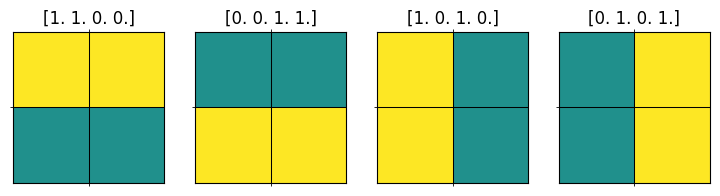

In [23]:
global n_qubits, hist_sample, n, m

n , m =  2, 2

bas = bars_and_stripes(n,m)

n_points, n_qubits  =  bas.shape

fig, ax_b = plt.subplots(1, bas.shape[0], figsize=(9,2))   #visualization of bars and stripes data set

for i in range(bas.shape[0]):
    ax_b[i].matshow(bas[i].reshape(n, m), vmin=-1, vmax=1)

    ax_b[i].set_xticks([])
    ax_b[i].set_yticks([])

    ax_b[i].set_xticks([0.5], minor=True);
    ax_b[i].set_yticks([0.5], minor=True);

    ax_b[i].set_title(bas[i])
    ax_b[i].grid(which='minor', color='black', linestyle='-', linewidth=0.75)

'''sample distribution'''
hist_sample = get_histogram(bas)

## Toplogies


In [24]:
import networkx as nx

edges_all_connected = []
edges_star          = []
edges_line          = []

''' line topology'''
for i in range(n_qubits-1):
    connections = [i,i+1]
    edges_line.append(connections)


'''star topology'''
for i in range(1,n_qubits):
    connections = [0,i]
    edges_star.append(connections)


'''all connected topology'''
for i in range(n_qubits-1):
    for j in range(i+1,n_qubits):
        connections = [i,j]
        edges_all_connected.append(connections)

# Or build any other you would like to explore. For example, ring topology?


'''lets define a little function for the connections'''
def top(x):
    if x == 0:
        edges = edges_line
    if x == 1:
        edges = edges_star
    if x == 2:
        edges = edges_all_connected
    return edges

### Circuit parameters

In [25]:
global n_top, single_g, entangling_g, n_layers, dimension, machine
global min_bounds, max_bounds, n_rotations, init_state, n_measurements, q_arrange

'''define the topology and initial state'''
n_top = 2             # options: 0 - line, 1 - star,  2 - all connected
init_state = 'zero'   # options: zero and hadammard

'''define single and entangling gates'''
single_g      =  ['RY','RZ']
entangling_g  =  ['YY']       # options YY, ZZ, CPHASE -- the entangling gate can be modify in the circuit

'''define the number of layers'''
n_layers = 2

'''number of parameters'''
n_rotations   = len(single_g)
even_n_layers = int(np.floor(n_layers/2))
odd_n_layers  = n_layers - even_n_layers
if single_g[0] == 'RZ' and init_state == 'zero':
    dimension     = (n_rotations*odd_n_layers-1)*n_qubits + len(top(n_top))*even_n_layers
else:
    dimension     = (n_rotations*odd_n_layers)*n_qubits + len(top(n_top))*even_n_layers

### Quantum Circuit: Instructions to the quantum computer

In [26]:
def circuit(angles: np.ndarray) -> list[float]:
    """
    Build and simulate a variational quantum circuit for the given parameters.

    Constructs a layered ansatz circuit and returns the Born-rule probability
    distribution over all ``2**n_qubits`` computational basis states.

    Circuit structure
    -----------------
    Layers alternate between two types:

    * **Odd layers** — single-qubit rotation gates (``RY``, ``RZ``, or ``RX``)
      applied to every qubit.  The gate sequence is controlled by the global
      ``single_g`` list.
    * **Even layers** — two-qubit entangling gates applied to qubit pairs
      defined by the topology ``top(n_top)``.  The entangling gate type is
      controlled by ``entangling_g[0]``:

      - ``'YY'`` → ``CNOT – RY – CNOT`` sandwich
      - ``'ZZ'`` → ``CNOT – RZ – CNOT`` sandwich
      - ``'XX'`` → ``CNOT – RX – CNOT`` sandwich

    All rotation angles are supplied in units of π, i.e. a value of ``1.0``
    in *angles* corresponds to a physical rotation angle of π radians.

    Parameters
    ----------
    angles : array-like, shape (dimension,)
        Flattened vector of real-valued circuit parameters.  The total number
        of parameters ``dimension`` is determined by the global circuit
        configuration (``n_qubits``, ``n_layers``, ``single_g``,
        ``entangling_g``, ``n_top``).  Parameters are consumed in layer-major,
        qubit-major order: all single-qubit gates in each odd layer are filled
        before moving to the next layer; entangling gate angles fill even
        layers in topology order.

    Returns
    -------
    list of float, length 2**n_qubits
        Probability of measuring each computational basis state.  Entry *i*
        corresponds to the state whose binary representation (zero-padded to
        ``n_qubits`` bits) equals ``np.binary_repr(i, n_qubits)``.  The list
        sums to 1 up to ``PRECISION`` decimal places.

    Raises
    ------
    ValueError
        If an unrecognised gate name appears in ``single_g`` or
        ``entangling_g[0]``.
    AssertionError
        If the output probabilities do not sum to 1 within ``PRECISION``
        decimal places (indicates a numerical or configuration error).

    Notes
    -----
    The function reads from the following module-level globals:

    ==================  =====================================================
    ``init_state``      ``'zero'`` → initialise all qubits in ``|0⟩``;
                        ``'hadamard'`` → initialise all qubits in ``|+⟩``.
    ``n_qubits``        Number of qubits in the register.
    ``n_layers``        Total number of alternating circuit layers.
    ``single_g``        List of single-qubit gate names, e.g. ``['RY','RZ']``.
    ``entangling_g``    List whose first element names the two-qubit gate,
                        e.g. ``['YY']``.
    ``n_top``           Integer index selecting the qubit connectivity
                        topology via ``top()``.
    ``qvm``             :class:`NumpyQVM` simulator instance.
    ``PRECISION``       Decimal places used in the normalisation assertion.
    ==================  =====================================================

    Examples
    --------
    >>> import numpy as np
    >>> # Assume globals are configured for a 2-qubit, 2-layer circuit
    >>> probs = circuit(np.zeros(dimension))
    >>> len(probs)
    4
    >>> round(sum(probs), 5)
    1.0
    """
    # initialise the qubit register
    if init_state == "zero":
        C = Program()
        for i in range(n_qubits):
            C += I(i)                          # explicit |0⟩ initialisation
    elif init_state == "hadamard":
        C = Program()
        for i in range(n_qubits):
            C += H(i)                          # uniform superposition |+⟩
    else:
        raise ValueError(f"Unknown init_state: '{init_state}'. Use 'zero' or 'hadamard'.")

    angle_idx = 0                              # pointer into the angles vector

    # build alternating single / entangling layers
    for ly in range(1, n_layers + 1):

        if ly % 2 == 1:
            # odd layer: single-qubit rotations
            for qb in range(n_qubits):
                for op in single_g:
                    x = angles[angle_idx] * np.pi   # angle in radians

                    if   op == "RY": C += RY(x, qb)
                    elif op == "RZ": C += RZ(x, qb)
                    elif op == "RX": C += RX(x, qb)
                    else:
                        raise ValueError(
                            f"Unrecognised single-qubit gate '{op}'. "
                            f"Supported: 'RX', 'RY', 'RZ'."
                        )
                    angle_idx += 1

        else:
            # even layer: two-qubit entangling gates
            for idx1, idx2 in top(n_top):
                x   = angles[angle_idx] * np.pi     # angle in radians
                ent = entangling_g[0]

                if ent == "YY":
                    C += CNOT(idx1, idx2)
                    C += RY(x, idx2)
                    C += CNOT(idx1, idx2)
                elif ent == "ZZ":
                    C += CNOT(idx1, idx2)
                    C += RZ(x, idx2)
                    C += CNOT(idx1, idx2)
                elif ent == "XX":
                    C += CNOT(idx1, idx2)
                    C += RX(x, idx2)
                    C += CNOT(idx1, idx2)
                else:
                    raise ValueError(
                        f"Unrecognised entangling gate '{ent}'. "
                        f"Supported: 'YY', 'ZZ', 'XX'."
                    )
                angle_idx += 1

    # simulate and extract probability distribution
    wf         = qvm.wavefunction(C)
    probs_dist = wf.get_outcome_probs()
    probs      = [
        probs_dist[np.binary_repr(i, n_qubits)]
        for i in range(2 ** n_qubits)
    ]

    assert round(sum(probs), PRECISION) == 1., (
        f"Probability distribution does not sum to 1 "
        f"(got {sum(probs):.{PRECISION+2}f}). Check circuit configuration."
    )
    return probs

### Kullback - Leibler cost function

In [27]:
def KL(angles: np.ndarray) -> float:
    """
    Compute the Kullback-Leibler divergence between the target and circuit distributions.

    Evaluates the KL divergence :math:`D_{\\text{KL}}(P \\| Q)` where *P* is
    the fixed empirical target distribution (``hist_sample``) and *Q* is the
    Born-rule distribution produced by the variational circuit for the given
    *angles*:

    .. math::

        D_{\\text{KL}}(P \\| Q) = \\sum_{i} P(i)\\,
        \\ln\\!\\left(\\frac{P(i)}{Q(i)}\\right)
        = \\sum_{i} \\Bigl[-P(i)\\ln Q(i) + P(i)\\ln P(i)\\Bigr]

    Both :math:`P(i)` and :math:`Q(i)` are clipped to ``[CLIP, 1]`` before
    the logarithm to prevent numerical instability when either distribution
    has near-zero entries.

    Parameters
    ----------
    angles : array-like, shape (dimension,)
        Flattened vector of variational circuit parameters, passed directly to
        :func:`circuit`.  Values are interpreted in units of π.

    Returns
    -------
    float
        Non-negative KL divergence in nats.  A value of ``0.0`` indicates that
        the circuit distribution exactly matches the target.

    Notes
    -----
    * This function reads the module-level globals ``hist_sample``,
      ``n_qubits``, and ``CLIP``.
    * Because :math:`D_{\\text{KL}}` is not symmetric, the target *P* must
      always be the first argument; swapping *P* and *Q* yields a different
      (and generally larger) value.
    * The term :math:`\\sum_i P(i)\\ln P(i)` is constant with respect to the
      circuit angles and acts as a baseline offset, ensuring the minimum
      achievable loss is ``0.0`` rather than a negative value.

    Examples
    --------
    >>> import numpy as np
    >>> # Perfect match: circuit reproduces the target → KL ≈ 0
    >>> loss = KL(optimal_angles)
    >>> round(loss, 4)
    0.0

    >>> # Random angles will give a positive divergence
    >>> loss = KL(np.random.uniform(-1, 1, dimension))
    >>> loss > 0
    True

    See Also
    --------
    circuit : Builds and simulates the variational ansatz.
    """
    probs = circuit(angles)

    kl_divergence = sum(
        -hist_sample[i] * np.log(np.clip(probs[i],        CLIP, 1.0))
        + hist_sample[i] * np.log(np.clip(hist_sample[i], CLIP, 1.0))
        for i in range(2 ** n_qubits)
    )

    return float(kl_divergence)

### Optimizer: Particle Swarm optimization

In [28]:
c1           = 1.0
c2           = 1.0
w            = 0.5
particles    = 2*dimension
n_iterations = 30

np.random.seed(4)

optimizer = PSO(
            n_parameters = dimension,
            n_particles  = particles,
            phip         = 1.0,
            phig         = 1.0,
            omega        = 0.5,
            type         = 'circular')

batch =  optimizer.x

### Training process

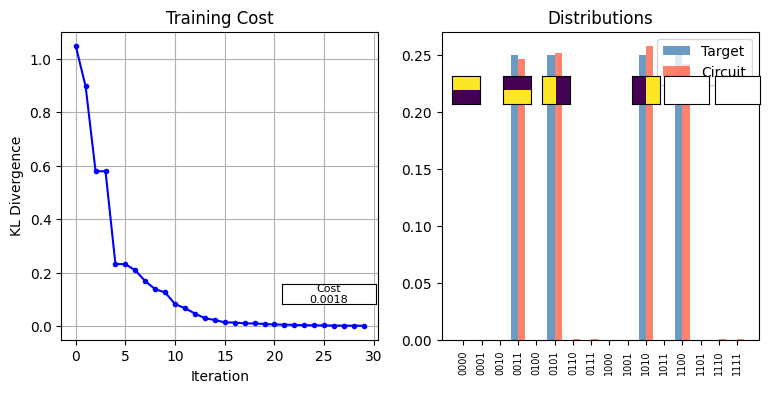

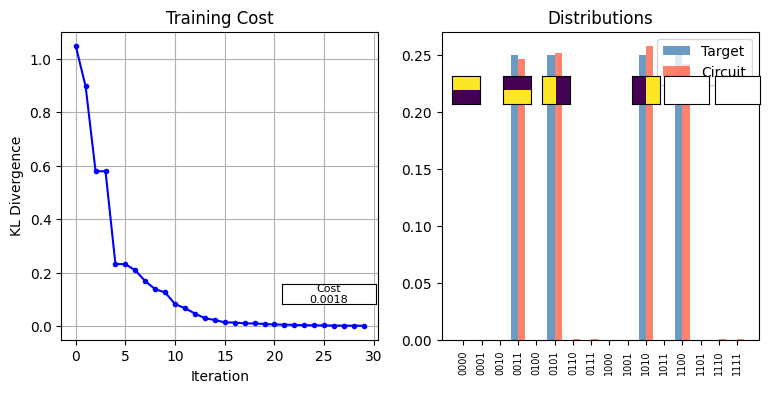

In [31]:
save_filename = 'Trial1_top-all_'
file_path = str(save_filename) + 'cost_and_angles_all.txt'
f = open(file_path, 'w')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
ax_c = fig.add_axes([0.37,0.2,0.105,0.05])
y_position, width, height = 0.7, 0.05, 0.07
ax_b = []
ax_b.append(fig.add_axes([0.55,y_position,width,height]))
ax_b.append(fig.add_axes([0.606,y_position,width,height]))
ax_b.append(fig.add_axes([0.65,y_position,width,height]))
ax_b.append(fig.add_axes([0.75,y_position,width,height]))
ax_b.append(fig.add_axes([0.795,y_position,width,height]))
ax_b.append(fig.add_axes([0.851,y_position,width,height]))


best_angles = []
best_costs = []
best_histogram = []

for i in range(n_iterations):

    costs       = [KL(batch[p]) for p in range(particles)]
    costs       = np.array(costs).reshape((particles,))

    b_angles, b_cost, _, _  = optimizer.run(costs)
    b_hist = circuit(b_angles)

    best_angles.append(b_angles)
    best_costs.append(b_cost)
    best_histogram.append(circuit(b_angles))

    batch = optimizer.x

    f.write('%s \t' % i)
    f.write('%s \t' % b_cost)
    for item in b_angles:
        f.write("%s \t" % item)
        f.write('\n')

    plots(ax1,ax2,ax_b,ax_c,fig,best_costs,bas,hist_sample,b_hist,n,m)

    if i == 1:
        time.sleep(10)